# Component example: (PML) Plane Wave Scattering off a Dielectric Cube 

FDTD (Yee, 1966) FDTD discretizes Maxwell's curl equations directly:

$$\nabla \times \mathbf{E} = -\mu \frac{\partial \mathbf{H}}{\partial t}, \qquad\nabla \times \mathbf{H} = \varepsilon \frac{\partial \mathbf{E}}{\partial t}$$

Space is divided into a **Yee lattice** where:- **E** components sit on cell edges,- **H** components sit on face centers,- offset by half a cell in every direction.Time is likewise staggered by half a step. Replacing every derivative with a central difference (second-order accurate, error $\sim O(\Delta x^2)$) turns the PDE into a fully explicit update. For example, in 1D:

$$H_y^{q+1/2} = H_y^{q-1/2} + \frac{\Delta t}{\mu \Delta x} \left( E_z^q[m+1] - E_z^q[m] \right)$$

$$E_z^{q+1} = E_z^q + \frac{\Delta t}{\varepsilon \Delta x} \left( H_y^{q+1/2}[m+\tfrac{1}{2}] - H_y^{q+1/2}[m-\tfrac{1}{2}] \right)$$

This is the **leap-frog scheme**: $H$ is updated from $E$, then $E$ from the new $H$, forever — **no matrix solve needed**. For stability the Courant number must satisfy:

$$S_c = \frac{c \, \Delta t}{\Delta x} \leq \frac{1}{\sqrt{D}}$$

for $D$ spatial dimensions ($D=3$ here). This is why `courant_factor=0.99` scales $\Delta t$ just under that bound.

### Boundaries

**PML** (Bérenger, 1994) | Fictitious lossy, reflectionless medium surrounding the $z$-faces. Impedance-matched at all angles/frequencies in the continuous limit. Exponentially damps outgoing waves before they reach the domain edge. | Lets a finite box mimic **open space** in $z$. || 

**Periodic** | Identifies $x / x+L_x$ and $y / y+L_y$ faces. Fields exiting one side re-enter the other. | Models an **infinite tiled plane** in $x$ and $y$. |> For a normal-incidence wave (in-plane wavevector $k_{\parallel}=0$, as here) simple periodicity suffices. For **oblique incidence** you would need Bloch/Floquet periodic boundaries with a phase shift $e^{i k_{\parallel} \cdot L}$ between opposite faces (`fdtdx` exposes this as `BlochBoundary`).---

This notebook walks through a minimal **FDTD** (Finite-Difference Time-Domain) simulation using the [`fdtdx`](https://fdtdx.readthedocs.io) package. **What we simulate:** A normally-incident plane wave (Ex-polarized, propagating in $-z$) hits a dielectric cube.- Boundaries: **PML** at $-z$ and $+z$ (absorbing), **periodic** at $x$ and $y$ (models an infinite plane wave / infinite periodic array).

## 1. Imports

We need JAX for automatic differentiation and array operations, Matplotlib for plotting, and `fdtdx` for the FDTD engine.

In [210]:
import time 
import jax
import jax.numpy as jnp
from matplotlib import pyplot as plt
import fdtdx
from IPython.display import Video

%matplotlib inline

## 2. RNG Key & Simulation Config

`fdtdx` is built on JAX, so we start with a PRNG key for any stochastic operations.The `SimulationConfig` defines the core numerical parameters 

**Why `courant_factor=0.99`?**  The Courant number $S_c = c \Delta t / \Delta x$ must satisfy $S_c \leq 1/\sqrt{D}$ in $D$ dimensions (here $D=3$) for the explicit leap-frog scheme to remain stable. A factor of 0.99 places $\Delta t$ just under that bound for accuracy without instability.

In [213]:
key = jax.random.PRNGKey(42)
object_list = []

config = fdtdx.SimulationConfig(
    time=100e-15,          # total simulated time: 100 fs
    grid=fdtdx.UniformGrid(spacing=100e-9),     # Yee-cell edge length: 100 nm (dx = dy = dz)
    dtype=jnp.float32,
    courant_factor=0.99,
)

## 3. Simulation Volume

The `SimulationVolume` defines the physical bounding box and the background material. Here we use a $8 \times 8 \times 10$ micron box filled with vacuum ($\varepsilon = \mu = 1$).

In [216]:
volume = fdtdx.SimulationVolume(
    partial_real_shape=(8e-6, 8e-6, 10e-6),   # 8 x 8 x 10 micron box    
    material=fdtdx.Material(permittivity=1.0, permeability=1.0),
)
object_list.append(volume)
constraints = []

## 4. Boundaries

We need the finite simulation box to behave like open space in $z$ and like an infinite tiled plane in $x$ and $y$.

**PML (Perfectly Matched Layer)-** Surrounds the $z$-faces with a fictitious lossy, reflectionless medium.- Impedance-matched at all angles and frequencies (in the continuous limit).- Exponentially damps outgoing waves before they reach the domain edge.- `fdtdx` implements the **CPML / uniaxial variant** (Gedney, 1996) used in most modern codes.

**Periodic Boundaries-** Identify the $x / x+L_x$ and $y / y+L_y$ faces.- Fields that exit one side re-enter the other. Combined with a source that spans the full cross-section, this models a **genuinely infinite, uniform-amplitude plane wave**. **How the code works:** 

`BoundaryConfig.from_uniform_bound(boundary_type="periodic", ...)` sets periodic boundaries everywhere by default. The `override_types={"min_z": "pml", "max_z": "pml"}` then overrides **only** the two $z$-faces to PML — exactly the "PML top/bottom, periodic elsewhere" setup.

In [219]:
bound_cfg = fdtdx.BoundaryConfig.from_uniform_bound(
    boundary_type="periodic",       # default: x, y    
    thickness=10,                   # PML thickness in cells    
    override_types={"min_z": "pml", "max_z": "pml"},  # override z faces
)
bound_dict, bound_constraints = fdtdx.boundary_objects_from_config(bound_cfg, volume)
object_list.extend(bound_dict.values())
constraints.extend(bound_constraints)

## 5. Plane-Wave Source

We inject an **Ex-polarized** plane wave travelling in the $-z$ direction ("downwards").

Key details:- `partial_grid_shape=(None, None, 1)` — the source is exactly **1 cell thick** in $z$.- `source.same_size(volume, axes=(0, 1))` — the source spans the **entire $x$-$y$ cross-section**.- `direction="-"` — wave propagates toward decreasing $z$.- `wave_character=fdtdx.WaveCharacter(wavelength=1.55e-6)` — telecom C-band ($\lambda = 1.55$ µm). **Why this is a true infinite plane wave:**  Because the source spans the full $x$-$y$ face **and** the $x$/$y$ boundaries are periodic, there are no edge effects. The field is uniform in amplitude across the entire cross-section — not a Gaussian-apodized beam.

In [222]:
source = fdtdx.UniformPlaneSource(
    partial_grid_shape=(None, None, 1),
    fixed_E_polarization_vector=(1, 0, 0),
    wave_character=fdtdx.WaveCharacter(wavelength=1.55e-6),  # telecom C-band
    direction="-",
)
object_list.append(source)
constraints.extend([
    source.place_relative_to(
        volume, axes=(0, 1, 2),
        own_positions=(0, 0, 1), other_positions=(0, 0, 1),
        margins=(0, 0, -1.5e-6),  # sit 1.5 um in front of the +z PML
    ),
    source.same_size(volume, axes=(0, 1)),  # cover the entire x-y face
])

## 6. Dielectric Cube (Optional)

A small dielectric cube is placed at the center of the volume so the wave has something to scatter off — this makes the resulting video/field pattern more interesting. Delete this object if you want to simulate pure transmission through vacuum.

In [225]:
cube = fdtdx.UniformMaterialObject(
    partial_real_shape=(2e-6, 2e-6, 2e-6),
    material=fdtdx.Material(permittivity=2.5),
    name="Cube",
)
object_list.append(cube)
constraints.append(cube.place_at_center(volume))

## 7. Detector

An `EnergyDetector` records the electromagnetic energy density every 3rd time step. Setting `as_slices=True` tells it to store 2D slices suitable for making a video.

In [228]:
video = fdtdx.EnergyDetector(
    name="Video",
    as_slices=True,
    switch=fdtdx.OnOffSwitch(interval=3),
    exact_interpolation=True,
)
object_list.append(video)
constraints.extend(video.same_position_and_size(volume))

## 8. Resolve Constraints & Plot Setup

`fdtdx.place_objects` resolves all relative positioning constraints into concrete grid arrays. We then plot the simulation geometry to verify everything looks correct before running.

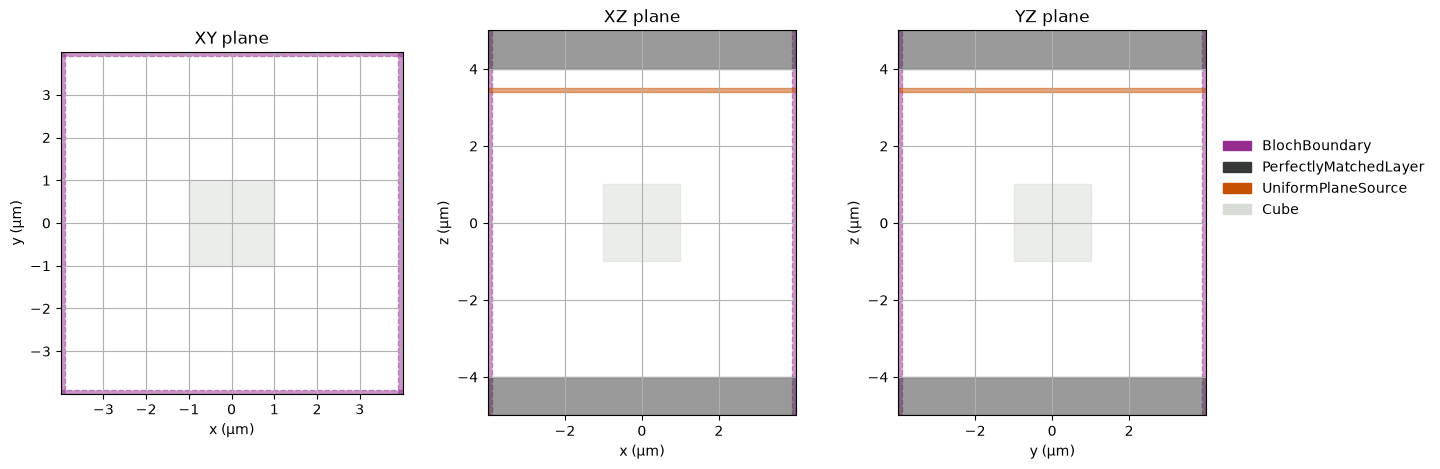

In [231]:
key, subkey = jax.random.split(key)
objects, arrays, params, config, _ = fdtdx.place_objects(
    object_list=object_list, config=config, constraints=constraints, key=subkey,
)

fig = fdtdx.plot_setup(config=config, objects=objects, exclude_object_list=[video])
plt.show()

## 9. Run the FDTD Loop

The simulation function is JIT-compiled with `jax.jit` for maximum performance on GPU/TPU.**What happens inside `run_fdtd`:**

1. Apply any parameterized material maps (`apply_params`).
2. Execute the explicit Yee-algorithm time-stepping loop.
3. Return the final field state and any detector recordings.

In [234]:
def sim_fn(params, arrays, key):
    arrays, new_objects, _ = fdtdx.apply_params(arrays, objects, params, key)
    final_state = fdtdx.run_fdtd(arrays=arrays, objects=new_objects, config=config, key=key)
    _, arrays = final_state
    return arrays


jitted_sim = jax.jit(sim_fn)

t0 = time.time()
new_arrays = jitted_sim(params, arrays, subkey)
print(f"Simulation runtime: {time.time() - t0:.2f} s")

FDTD (checkpointed):   0%|                            | 0/525 [00:00<?, ?step/s]

Simulation runtime: 2.62 s


## 10. Video

The detector object stores the energy density at each recorded timestep. `draw_plot` renders these frames into a video file.

In [237]:
video_paths = objects["Video"].draw_plot(new_arrays.detector_states["Video"])

if isinstance(video_paths, (list, tuple)):
    path_to_show = video_paths[0]
elif isinstance(video_paths, dict):
    path_to_show = list(video_paths.values())[0]
else:
    path_to_show = video_paths

display(Video(path_to_show, embed=True))

## 12. References

1. **K. S. Yee**, "Numerical solution of initial boundary value problems involving Maxwell's equations in isotropic media," *IEEE Trans. Antennas Propag.*, 14(3):302–307, 1966. *(original FDTD paper)*
2. **A. Taflove & S. C. Hagness**, *Computational Electrodynamics: The Finite-Difference Time-Domain Method*, 3rd ed., Artech House, 2005. *(the standard FDTD textbook)*
3. **J.-P. Bérenger**, "A perfectly matched layer for the absorption of electromagnetic waves," *J. Comput. Phys.*, 114(2):185–200, 1994. *(original PML)*
4. **S. D. Gedney**, "An anisotropic perfectly matched layer-absorbing medium for the truncation of FDTD lattices," *IEEE Trans. Antennas Propag.*, 44(12):1630–1639, 1996. *(UPML/CPML used in practice)*
5. **J. B. Schneider**, *Understanding the Finite-Difference Time-Domain Method*, free online textbook, 2010 — this is the source `fdtdx`'s own docs cite for their physics tutorials.
6. **Y. Mahlau, F. Schubert, L. Berg, B. Rosenhahn**, "FDTDX: High-Performance Open-Source FDTD Simulation with Automatic Differentiation," *J. Open Source Softw.*, 11(117):8912, 2026 — the `fdtdx` package paper itself.